# Предсказание растворимости на базе AqSolDB

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

from rdkit import Chem
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Draw
from rdkit import DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem import PandasTools

import matplotlib.pyplot as plt

from rdkit import RDLogger
# Отключаем все логи/предупреждения RDKit
RDLogger.DisableLog('rdApp.*')

Считаем БД, оставив только колонки SMILES и Solubility

In [ ]:
aqsoldb = pd.read_csv('AqSolDB.csv')

aqsoldb = aqsoldb[['SMILES', 'Solubility']]

aqsoldb

,SMILES,Solubility
0,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127
1,O=C1Nc2cccc3cccc1c23,-3.254767
2,Clc1ccc(C=O)cc1,-2.177078
3,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409
4,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065
...,...,...
9977,C(c1ccc(cc1)NCCCC)(=O)OCCN(C)C,-3.010000
9978,OC1=C(C(C2=C(O)[C@@](C(C(C(N)=O)=C(O)[C@H]3N(C...,-2.930000
9979,c1(cc(ccc1C(C)C)C)O,-2.190000
9980,COc1ccc(CCN(C)CCCC(C#N)(C(C)C)c2ccc(OC)c(OC)c2...,-3.980000


Проведем отбор валидных SMILES

In [ ]:
# Определяем функцию, которая проверяет, является ли строка SMILES корректной
def is_valid_smiles(smiles):
    # Chem.MolFromSmiles пытается преобразовать строку SMILES в объект молекулы.
    # Если строка некорректна, возвращается None.
    return Chem.MolFromSmiles(smiles) is not None

# Фильтруем DataFrame aqsoldb, оставляя только те строки,
# в которых значение в столбце 'SMILES' представляет собой корректную молекулу.
# Для этого применяем функцию is_valid_smiles к каждому элементу столбца 'SMILES'.
# Метод apply() позволяет применить функцию ко всем элементам столбца.
aqsoldb = aqsoldb[aqsoldb['SMILES'].apply(is_valid_smiles)].reset_index(drop=True)

# Выводим количество оставшихся строк после фильтрации
len(aqsoldb)

9982

In [ ]:
X = aqsoldb['SMILES'] #для облегчения работы можно ограничиться первой тысячей записей вместо всей БД
y = aqsoldb['Solubility'] #иначе этап расчёта всех дескрипторов может занять до 10 минут

# Делим данные на обучающую и тестовую выборки:
# - X_train: SMILES для обучения модели
# - X_test:  SMILES для тестирования модели
# - y_train: известные значения растворимости для обучения
# - y_test:  известные значения растворимости для тестирования
#
# test_size=0.2 означает, что 20% данных будет использовано для тестирования (200 из 1000)
# random_state=42 гарантирует воспроизводимость разбиения при повторных запусках
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Линейная регрессия на базе молекулярных дескрипторов

### Предобработка данных

Здесь мы создадим из полученных тренировочной и тестовой выборок массивы признаков (фичей), пригодных для обработки моделями ML

In [ ]:
# Определяем функцию, которая будет рассчитывать дескрипторы RDKit для списка SMILES
def RDkit_descriptors(smiles):
    # Преобразуем каждую строку SMILES в объект молекулы (mol) с помощью RDKit
    # Мы уверены, что данная строка сработает, поскольку ранее отфильтровали невалидные SMILES
    mols = [Chem.MolFromSmiles(i) for i in smiles]

    # Создаём объект для вычисления молекулярных дескрипторов
    # [x[0] для x в Descriptors._descList] — это список названий всех доступных дескрипторов
    # Подробнее с классом MoleculeDescriptors можно ознакомиться в RDKit
    calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])

    # Получаем имена всех дескрипторов, чтобы потом знать, какой номер какому дескриптору соответствует
    desc_names = calc.GetDescriptorNames()

    # Список для хранения списков дескрипторов для каждой молекулы
    Mol_descriptors = []

    # Организуем цикл по перебору всех молекул из списка созданных mol
    for mol in mols:
        # Добавляем атомы водорода к молекуле — некоторые дескрипторы требуют их наличия
        mol = Chem.AddHs(mol)

        # Вычисляем дескрипторы для текущей молекулы
        descriptors = calc.CalcDescriptors(mol)

        # Добавляем результаты в общий список
        Mol_descriptors.append(descriptors)

    # Возвращаем два значения:
    # - список списков/кортежей с численными значениями дескрипторов
    # - список имён дескрипторов (пригодится для анализа результатов)
    return Mol_descriptors, desc_names

# Применяем функцию к обучающей и тестовой выборкам SMILES (этот процесс называют фичуризацией)
desc_train, desc_names = RDkit_descriptors(X_train)
desc_test, _ = RDkit_descriptors(X_test)

Выведем размеры полученных датасетов

In [ ]:
print(f'Размер обучающей выборки - {len(desc_train)}, тестовой - {len(desc_test)}')

Размер обучающей выборки - 7985, тестовой - 1997


In [ ]:
# Преобразуем список дескрипторов (desc_train), полученный из RDKit,
# в двумерный массив NumPy. Каждая строка — это молекула, каждый столбец — дескриптор.
desc_train_np = np.array(desc_train)

# Проверяем, есть ли в каком-либо из дескрипторов значение NaN (Not a Number).
# ~ — означает "не", то есть мы выбираем те строки, где НЕТ NaN ни в одном из столбцов.
non_nan_mask = ~np.isnan(desc_train_np).any(axis=1)

# Оставляем только те строки дескрипторов, где нет пропущенных значений (NaN)
desc_train_clean = desc_train_np[non_nan_mask]

# Соответствующие значения растворимости (y_train) тоже нужно очистить от тех же NaN,
# сохранив соответствие между молекулами и их растворимостью.
# .values преобразует Series pandas в массив NumPy.
y_train_clean = y_train.values[non_nan_mask]


# То же самое проделываем с тестовой выборкой дескрипторов

# Преобразуем тестовые дескрипторы в массив NumPy
desc_test_np = np.array(desc_test)

# Создаем маску для строк без NaN
non_nan_mask = ~np.isnan(desc_test_np).any(axis=1)

# Фильтруем тестовые дескрипторы
desc_test_clean = desc_test_np[non_nan_mask]

# И соответствующие им значения растворимости
y_test_clean = y_test.values[non_nan_mask]

Посмотрим, как изменились размеры выборок:

In [ ]:
print(f'Размер обучающей выборки - {len(desc_train_clean)}, тестовой - {len(desc_test_clean)}')

Размер обучающей выборки - 7273, тестовой - 1825


### Обучение и тестирование моделей

In [ ]:
# Создаём модель линейной регрессии
linear = LinearRegression()

# Обучаем модель на очищенных обучающих данных:
# - desc_train_clean — матрица дескрипторов (признаки)
# - y_train_clean — известные значения растворимости (целевая переменная)
linear.fit(desc_train_clean, y_train_clean)

# Делаем предсказания на тестовых данных
# model.predict() возвращает предсказанные значения растворимости для тестовой выборки
y_pred = linear.predict(desc_test_clean)

# Вычисляем и выводим метрики качества модели

# MSE (Mean Squared Error) — среднеквадратичная ошибка
# Чем меньше — тем лучше. Показывает, насколько в среднем предсказание отличается от правильного значения.
print("  Test MSE:", mean_squared_error(y_test_clean, y_pred))

# R² (коэффициент детерминации)
# Показывает, насколько хорошо модель объясняет вариацию целевой переменной.
# Значение близкое к 1 — хорошая модель; близкое к 0 — модель плохо описывает данные.
print("  Test R2:", r2_score(y_test_clean, y_pred))

  Test MSE: 5.335397857264004
  Test R2: -0.0004925911872712962


Наблюдаемые результаты очень и очень плохие. Возможно, линейная регрессия переобучилась? Проверим, используя описанные на лекции методы регуляризации (ограничения сложности модели)

In [ ]:
# Используем модель Lasso-регрессии — это метод линейной регрессии с регуляризацией L1
# alpha — сила регуляризации: чем больше значение, тем сильнее упрощается модель
# max_iter=10000 — увеличиваем максимальное число итераций для лучшей сходимости
lasso = Lasso(alpha=0.1, max_iter=10000)

# Обучаем модель Lasso на очищенных обучающих данных
lasso.fit(desc_train_clean, y_train_clean)

# Делаем предсказания на тестовых данных с помощью Lasso
y_pred_lasso = lasso.predict(desc_test_clean)

# Выводим метрики качества для модели Lasso
print("Lasso Regression:")
print("  Test MSE:", mean_squared_error(y_test_clean, y_pred_lasso))
print("  Test R2:", r2_score(y_test_clean, y_pred_lasso))

E:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: RuntimeWarning: overflow encountered in square
  model = cd_fast.enet_coordinate_descent(


Lasso Regression:
  Test MSE: 2.243119512491826
  Test R2: 0.5793707398333523


E:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.467e+03, tolerance: 3.964e+00
  model = cd_fast.enet_coordinate_descent(


Удивительно, но у меня модель заработала с R2 = 0.58. Тем не менее, у вас она может выдать кошмар или вообще не обучиться - причину приведем чуть позже, а пока попробуем обучить Ridge

In [ ]:
# Теперь обучаем Ridge-регрессию — это линейная регрессия с регуляризацией L2
# alpha — аналогично, задаёт силу регуляризации
ridge = Ridge(alpha=1.0)

# Обучаем модель Ridge на тех же обучающих данных
ridge.fit(desc_train_clean, y_train_clean)

# Делаем предсказания на тестовых данных с помощью Ridge
y_pred_ridge = ridge.predict(desc_test_clean)

# Выводим метрики качества для модели Ridge
print("Ridge Regression:")
print("  Test MSE:", mean_squared_error(y_test_clean, y_pred_ridge))
print("  Test R2:", r2_score(y_test_clean, y_pred_ridge))

ValueError: array must not contain infs or NaNs

Конкретно у меня Ridge вообще не завелась с жуткой ошибкой. Причина проблем (в частности, семинарских) довольно занятная. Посмотрим на разницу каких-нибудь соседних записей

In [ ]:
# desc_train_np — это NumPy-массив, где каждая строка — это набор дескрипторов одной молекулы.
# То есть desc_train_np[0] — это первый набор дескрипторов (первая молекула)
#       desc_train_np[1] — это второй набор дескрипторов (вторая молекула)

# Вычитаем поэлементно дескрипторы второй молекулы из первой:
desc_train_np[0] - desc_train_np[1]

# Затем вычисляем сумму всех полученных разностей:
(desc_train_np[0] - desc_train_np[1]).sum()

-1333798.2121540052

Число превышает 1 000 000. Поскольку мы опираемся на числовые методы оптимизации, это очень большая проблема для моделей - какие-то из дескрипторов внутри настолько сильно отличаются, что строимая нами многомерная регрессия "теряется" в таком разреженном и огромном пространстве. Это не будет проблемой для деревьев решений, например, но классическая оптимизация к такому может оказаться очень и очень чувствительной. Чтобы избежать таких проблем можно также воспользоваться масштабированием всех признаков (например, мы можем добиться того, чтобы наши признаки примерно приняли вид стандартных нормальных распределений при помощи StandardScaler из sklearn, но мы поступим чуть умнее)

Вместо расчёта абсолютно всех дескрипторов, рассчитаем только несколько самых важных для определения растворимости молекулы

In [ ]:
# Определяем функцию, которая вычисляет определённые нами дескрипторы для списка SMILES
def RDkit_descriptors_few(smiles):
    # Преобразуем каждую строку SMILES в объект молекулы (mol)
    # Chem.MolFromSmiles — это функция RDKit, которая создаёт объект молекулы из строки SMILES
    mols = [Chem.MolFromSmiles(i) for i in smiles]

    # Создаём пустой список, куда будем добавлять посчитанные дескрипторы для каждой молекулы
    Mol_descriptors = []

    # Для каждой молекулы вычисляем несколько важных дескрипторов
    for mol in mols:
        # LogP — коэффициент распределения между октанолом и водой. Мера липофильности.
        logp = Descriptors.MolLogP(mol)

        # MolWt — точная молекулярная масса соединения
        molwt = Descriptors.ExactMolWt(mol)

        # HBD — количество доноров водородных связей (по правилу Липинского)
        HBD = rdMolDescriptors.CalcNumHBD(mol)

        # HBA — количество акцепторов водородных связей (тоже по правилу Липинского)
        HBA = rdMolDescriptors.CalcNumHBA(mol)

        # Добавляем рассчитанные дескрипторы в общий список
        Mol_descriptors.append((logp, molwt, HBD, HBA))

    return Mol_descriptors

Теперь проведем такую же предобработку данных, как и ранее

In [ ]:
desc_train = RDkit_descriptors_few(X_train)
desc_test = RDkit_descriptors_few(X_test)

desc_train_np = np.array(desc_train)
non_nan_mask = ~np.isnan(desc_train_np).any(axis=1)
desc_train_clean = desc_train_np[non_nan_mask]
y_train_clean = y_train.values[non_nan_mask]

desc_test_np = np.array(desc_test)
non_nan_mask = ~np.isnan(desc_test_np).any(axis=1)
desc_test_clean = desc_test_np[non_nan_mask]
y_test_clean = y_test.values[non_nan_mask]

А также обучим все три модели

In [ ]:
linear = LinearRegression()
linear.fit(desc_train_clean, y_train_clean)
y_pred_linear = linear.predict(desc_test_clean)

lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(desc_train_clean, y_train_clean)
y_pred_lasso = lasso.predict(desc_test_clean)

# Train Ridge model
ridge = Ridge(alpha=1.0)
ridge.fit(desc_train_clean, y_train_clean)
y_pred_ridge = ridge.predict(desc_test_clean)


print("Linear Regression:")
print("  Test MSE:", mean_squared_error(y_test_clean, y_pred_linear))
print("  Test R2:", r2_score(y_test_clean, y_pred_linear))

print("Lasso Regression:")
print("  Test MSE:", mean_squared_error(y_test_clean, y_pred_lasso))
print("  Test R2:", r2_score(y_test_clean, y_pred_lasso))

print("Ridge Regression:")
print("  Test MSE:", mean_squared_error(y_test_clean, y_pred_ridge))
print("  Test R2:", r2_score(y_test_clean, y_pred_ridge))

#Сохраним ошибку линейной регрессии на будущее - она нам понадобится
mse_linear = mean_squared_error(y_test, y_pred_linear)

Linear Regression:
  Test MSE: 2.9430955617796637
  Test R2: 0.45745843230488237
Lasso Regression:
  Test MSE: 2.9354288151329238
  Test R2: 0.45887174990111024
Ridge Regression:
  Test MSE: 2.943094381390968
  Test R2: 0.45745864990227936


Теперь результат выходит в разы быстрее (4 признака против более 200 существенно упрощают вычисления), и воспроизводимо (регрессия всегда успешно разрешается)

### Подбор параметров регуляризации

Для начала обучим много различных Lasso моделей с различным гиперпараметром alpha и запишем все полученные ошибки

In [ ]:
# Создаём массив значений alpha (силы регуляризации) от 0.01 до 1.0 — всего 1000 значений
alphas = np.linspace(0.01, 1, 1000)

# Создаём пустой список для хранения ошибок модели (MSE) при разных значениях alpha
err = []

# Перебираем все значения alpha по очереди
for alpha in alphas:
    # Создаём модель Lasso-регрессии с текущим значением alpha
    lasso = Lasso(alpha=alpha)

    # Обучаем модель на очищенных обучающих данных
    lasso.fit(desc_train_clean, y_train_clean)

    # Делаем предсказания на тестовых данных
    y_pred = lasso.predict(desc_test_clean)

    # Считаем среднеквадратичную ошибку (MSE) между предсказанными и реальными значениями
    mse = mean_squared_error(y_pred, y_test_clean)

    # Добавляем эту ошибку в список err
    err.append(mse)

Изобразим что получилось

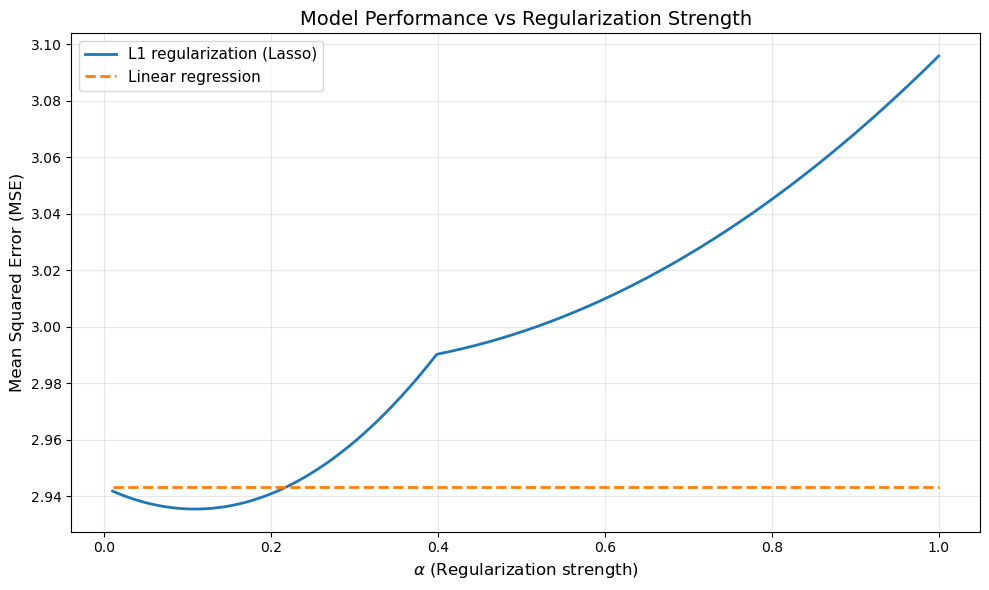

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(alphas, err, label='L1 regularization (Lasso)', linewidth=2)
plt.plot(alphas, [mse_linear]*len(alphas), label='Linear regression', linewidth=2, linestyle='--')
plt.xlabel(r'$\alpha$ (Regularization strength)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Model Performance vs Regularization Strength', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Теперь выведем оптимальные параметры модели Lasso

In [ ]:
# Находим минимальное значение ошибки (MSE) среди всех протестированных alpha
best_error_lasso = np.min(err)

# Находим значение alpha, при котором ошибка была минимальной
# err.index(min(err)) — находим индекс минимальной ошибки в списке err
# alphas[...] — находим соответствующее этому индексу значение alpha
best_alpha_lasso = alphas[err.index(min(err))]

In [ ]:
print(f'Минимальная MSE {best_error_lasso} при alpha {best_alpha_lasso}')

Минимальная MSE 2.935379465392937 при alpha 0.1090990990990991


Повторим вышеописанное для модели Ridge

In [ ]:
alphas = np.linspace(0.01, 10000, 1000)
err = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(desc_train_clean, y_train_clean)
    y_pred = ridge.predict(desc_test_clean)
    err.append(mean_squared_error(y_pred, y_test_clean))

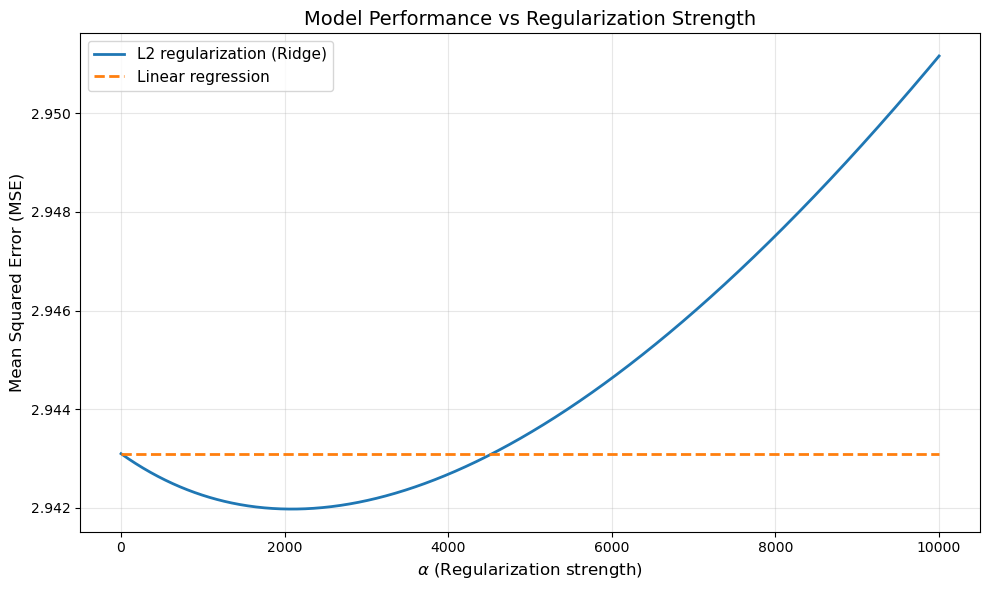

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(alphas, err, label='L2 regularization (Ridge)', linewidth=2)
plt.plot(alphas, [mse_linear]*len(alphas), label='Linear regression', linewidth=2, linestyle='--')
plt.xlabel(r'$\alpha$ (Regularization strength)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Model Performance vs Regularization Strength', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
best_error_ridge = np.min(err)
best_alpha_ridge = alphas[err.index(min(err))]

In [ ]:
print(f'Минимальная MSE {best_error_ridge} при alpha {best_alpha_ridge}')

Минимальная MSE 2.9419719378387725 при alpha 2082.09


В моем случае модель Lasso оказалась чуть лучше. Обучим модель использая определенный выше гиперпараметр best_alpha_lasso и изобразим график actual vs predicted

In [ ]:
lasso = Lasso(alpha=best_alpha_lasso)
lasso.fit(desc_train_clean, y_train_clean)
y_pred = lasso.predict(desc_test_clean)

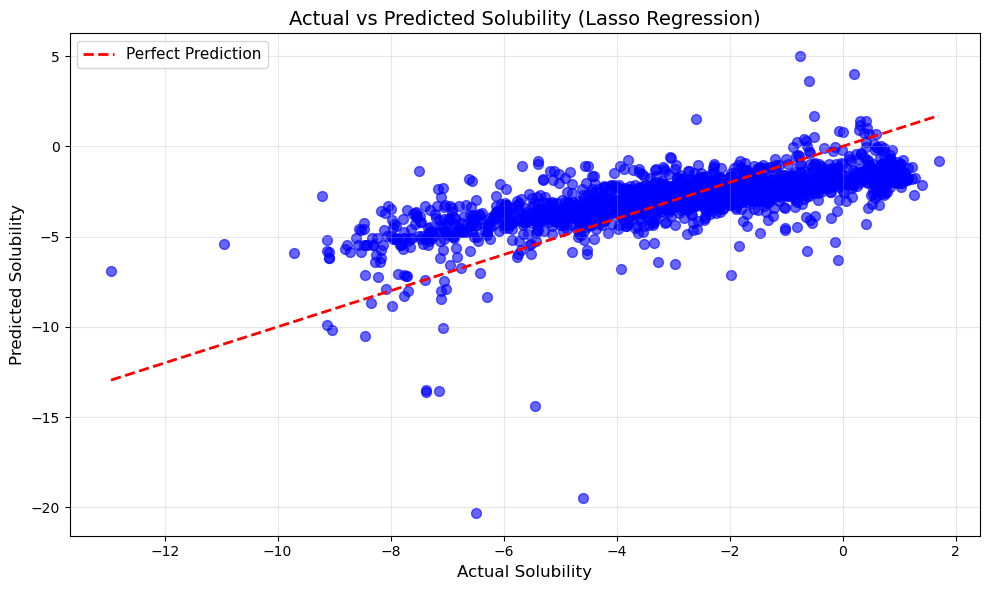

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Solubility', fontsize=12)
plt.ylabel('Predicted Solubility', fontsize=12)
plt.title('Actual vs Predicted Solubility (Lasso Regression)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Из этого графика видно, что наша регрессия очень далека от идеала - видимо, несколько сильно выраженных выбросов очень сильно смещают оценку параметров регрессии

## Линейная регрессия при помощи отпечатков Моргана (ECFP)

In [ ]:
# Используем PandasTools из RDKit для добавления нового столбца с молекулами в DataFrame
# AddMoleculeColumnToFrame — функция, которая:
#   - берёт SMILES из указанного столбца ('SMILES'),
#   - преобразует их в объекты молекул (типа rdkit.Chem.rdchem.Mol),
#   - и добавляет их как новый столбец с именем 'Molecule'
PandasTools.AddMoleculeColumnToFrame(aqsoldb, smilesCol='SMILES', molCol='Molecule')

,SMILES,Solubility,Molecule,fp
0,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,O=C1Nc2cccc3cccc1c23,-3.254767,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Clc1ccc(C=O)cc1,-2.177078,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...
9977,C(c1ccc(cc1)NCCCC)(=O)OCCN(C)C,-3.010000,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
9978,OC1=C(C(C2=C(O)[C@@](C(C(C(N)=O)=C(O)[C@H]3N(C...,-2.930000,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9979,c1(cc(ccc1C(C)C)C)O,-2.190000,,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9980,COc1ccc(CCN(C)CCCC(C#N)(C(C)C)c2ccc(OC)c(OC)c2...,-3.980000,,"[0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."

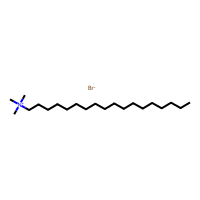
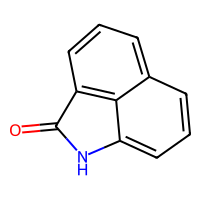
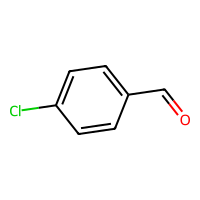
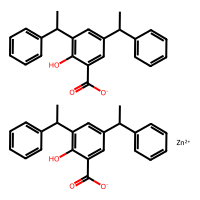
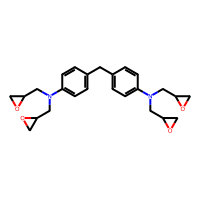
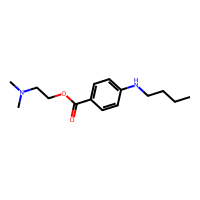
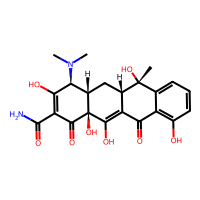
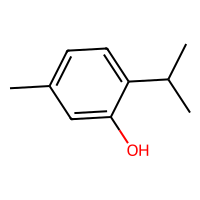
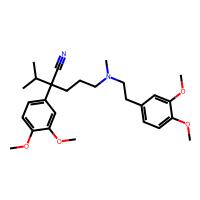
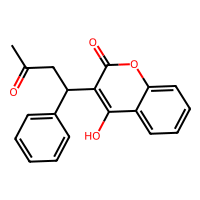

In [ ]:
# Добавляем новый столбец 'fp' (fingerprint — фингерпринт) в датафрейм aqsoldb
# Для каждой молекулы в столбце 'Molecule' вычисляем Morgan-фингерпринт

aqsoldb['fp'] = aqsoldb['Molecule'].apply(
    # Используем lambda-функцию для применения GetMorganFingerprintAsBitVect ко всем молекулам
    lambda m: AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=1024) #Выберем радиус 2 и 1024 бита в отпечатке моргана
)

# Выводим обновлённый датафрейм
aqsoldb

In [ ]:
#Снова разобьем на трейн и тест, на этот раз используя колонки таблицы
X_train, X_test, y_train, y_test = train_test_split(aqsoldb['fp'], aqsoldb['Solubility'], test_size=0.2, random_state=42)

In [ ]:
# Преобразуем каждый фингерпринт в X_train в NumPy-массив.
# Это нужно для совместимости с библиотеками машинного обучения, такими как scikit-learn.
X_train_fp = [np.array(x) for x in X_train]

# Преобразуем список целевых значений (растворимости) в NumPy-массив
y_train = np.array(y_train)

# То же самое делаем с тестовой выборкой:
X_test_fp = [np.array(x) for x in X_test]
y_test = np.array(y_test)

Теперь всё готово для обучения моделей аналогично экспериментам с дескрипторами

In [ ]:
linear = LinearRegression()
linear.fit(X_train_fp, y_train)
y_pred_linear = linear.predict(X_test_fp)

lasso = Lasso(alpha=1, max_iter=10000)
lasso.fit(X_train_fp, y_train)
y_pred_lasso = lasso.predict(X_test_fp)

# Train Ridge model
ridge = Ridge(alpha=10)
ridge.fit(X_train_fp, y_train)
y_pred_ridge = ridge.predict(X_test_fp)


print("Linear Regression:")
print("  Test MSE:", mean_squared_error(y_test, y_pred_linear))
print("  Test R2:", r2_score(y_test, y_pred_linear))

print("Lasso Regression:")
print("  Test MSE:", mean_squared_error(y_test, y_pred_lasso))
print("  Test R2:", r2_score(y_test, y_pred_lasso))

print("Ridge Regression:")
print("  Test MSE:", mean_squared_error(y_test, y_pred_ridge))
print("  Test R2:", r2_score(y_test, y_pred_ridge))

Linear Regression:
  Test MSE: 2.3176258789522466
  Test R2: 0.5727599218908193
Lasso Regression:
  Test MSE: 5.4254884287769425
  Test R2: -0.0001554267848586921
Ridge Regression:
  Test MSE: 2.196570638917224
  Test R2: 0.595075710939339


Заметим, что данный эксперимент (и фичуризация, и обучение моделей) происходит быстрее фичуризации дескрипторами, а также дает лучший результат. Тем не менее, до идеала нам еще далеко - могут помочь грамотные представления структуры (например, добавление в наш список из 4х дескрипторов каких-то дополнительных), более продвинутые модели и фильтрация выбросов из датасета

## Задание 1.
Изобразите график actual vs predicted для отпечатков Моргана, сравните с результатами, полученными для дескрипторов

In [ ]:
#Здесь будет ваш код

## Задание 2*.
Постройте функцию регрессии для растворимости, используя в качестве модели регрессию на основе дерева решений (DecisionTreeRegressor из sklearn), используя любые понравившиеся представления структуры (дескрипторы или отпечатки моргана). Сравните полученную среднеквадратичную ошибку с полученными ранее, изобразите график actual vs predicted

In [ ]:
#Здесь будет ваш код